In [92]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from src.utils import compose_model_dir
import pickle
import pprint
import json
import os
import yaml
from scipy.stats import ttest_1samp, sem, ttest_rel, false_discovery_control
from ipywidgets import widgets
import pyarrow.parquet as pq
from net2brain.evaluations.plotting import Plotting
from net2brain.evaluations.rsa import RSA


In [75]:
mpl.rcParams['axes.titlesize']=14
mpl.rcParams['axes.labelsize']=12
sns.set_context("paper", rc={"axes.labelsize":18, "axes.titlesize":20, "axes.ticklabelsize": 14})

In [3]:
available_dirs = os.listdir('results')

results_dropdown = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown)

Dropdown(options=('resnet50_t=5_gs=224_99e6c1e4', 'vit_base_t=15_gs=224_ed1a41d3_center_crop', 'vit_base_t=15_…

In [4]:
results_dir = results_dropdown.value
print(results_dir)

resnet50_t=5_gs=224_99e6c1e4


In [5]:
rsa_df_path = os.path.join("results",results_dir, "eval_df_rsa.parquet")
reg_df_path = os.path.join("results",results_dir, "eval_df_reg.parquet")

In [6]:
roi_cat=pd.read_csv('roi_categorization.csv', index_col=0)
roi_cat=roi_cat.rename(columns={"stream": "location/stream"})

# FDR correction and inspection of raw numbers

In [7]:
rsa_table = pq.read_table(rsa_df_path, partitioning=None)
rsa_df = rsa_table.to_pandas()
meta_rsa = rsa_table.schema.metadata["custom_meta".encode()]
meta_rsa = json.loads(meta_rsa)
pprint.pp(meta_rsa)

{'name': 'resnet50',
 'time_window': 5,
 'crop_size': 224,
 'center_crop': False,
 'layers': ['backbone.layer1',
            'backbone.layer2',
            'backbone.layer3',
            'backbone.layer4'],
 'evaluation': 'rsa',
 'distance_metric': 'spearman'}


In [8]:
rsa_df_fdr = rsa_df.copy()
rsa_df_fdr["Significance"] = false_discovery_control(rsa_df_fdr["Significance"].to_numpy())
rsa_df_fdr

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V3d_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.032584,39.403830,"[0.039883810214354935, 0.03857733288612634, 0....",0.000051,0.003512,0.082692,0.244442
1,V3d_lh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.042793,51.750022,"[0.058679586996697494, 0.05302045612004714, 0....",0.000040,0.004426,0.082692,0.244442
2,V3d_lh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.075786,91.648163,"[0.09307977774948739, 0.08678409729366156, 0.0...",0.000040,0.007844,0.082692,0.244442
3,V3d_lh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.087157,105.399236,"[0.09926905833616641, 0.0988318483734896, 0.05...",0.000043,0.009134,0.082692,0.244442
4,PPA_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.065015,38.278865,"[0.07031142723345536, 0.06892703987905507, 0.0...",0.000015,0.005585,0.169846,0.329043
...,...,...,...,...,...,...,...,...,...,...
131,V2d_rh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.092644,79.920456,"[0.11237000350937751, 0.09403014634356924, 0.0...",0.000007,0.006866,0.115920,0.279621
132,EBA_rh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.048609,12.589464,"[0.05074807083131314, 0.05003604922794997, 0.0...",0.000004,0.003136,0.386108,0.505474
133,EBA_rh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.051436,13.321619,"[0.054490209533940334, 0.05453891293349469, 0....",0.000004,0.003260,0.386108,0.505474
134,EBA_rh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.096090,24.886859,"[0.09786491586190214, 0.10182357623298169, 0.1...",0.000004,0.006143,0.386108,0.505474


In [9]:
reg_table = pq.read_table(reg_df_path, partitioning=None)
reg_df = reg_table.to_pandas()
reg_df.reset_index(inplace=True, drop=True)
meta_reg = reg_table.schema.metadata["custom_meta".encode()]
meta_reg = json.loads(meta_reg)
pprint.pp(meta_reg)

{'name': 'resnet50',
 'time_window': 5,
 'crop_size': 224,
 'center_crop': False,
 'layers': ['backbone.layer1',
            'backbone.layer2',
            'backbone.layer3',
            'backbone.layer4'],
 'evaluation': 'reg',
 'distance_metric': 'spearman',
 'n_folds': 3,
 'n_components': 100,
 'trn_tst_split': 0.8,
 'batch_size': 100}


In [10]:
reg_df_fdr = reg_df.copy()
reg_df_fdr["Significance"] = false_discovery_control(reg_df_fdr["Significance"].to_numpy())
reg_df_fdr

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V1v_rh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.425958,NaN,"[0.4555178457528973, 0.45958793562647443, 0.39...",1.566150e-06,0.023502,NaN,NaN
1,V1v_rh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.435943,NaN,"[0.46894183660034017, 0.473544096953393, 0.388...",1.566150e-06,0.024690,NaN,NaN
2,V1v_rh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.439192,NaN,"[0.47696976227629023, 0.48969151363787883, 0.3...",1.680022e-06,0.025830,NaN,NaN
3,V1v_rh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.412219,NaN,"[0.4379352742414557, 0.4447906945854232, 0.372...",1.566150e-06,0.023336,NaN,NaN
4,VWFA-2_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.147842,NaN,"[0.1420824662804634, 0.15931717706167167, 0.15...",1.293853e-04,0.019342,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
131,FFA-1_rh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.368483,NaN,"[0.3606195301294137, 0.43330906610500586, 0.38...",9.031910e-07,0.016270,NaN,NaN
132,OPA_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.242205,NaN,"[0.28166896829787896, 0.28083254256239926, 0.2...",2.650897e-05,0.023917,NaN,NaN
133,OPA_lh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.289969,NaN,"[0.33016544695021727, 0.3388737187415587, 0.27...",1.710479e-05,0.025880,NaN,NaN
134,OPA_lh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.334799,NaN,"[0.36724405709227215, 0.40601065896017347, 0.3...",2.340902e-05,0.032130,NaN,NaN


# Pooling left and right sides

In [12]:
roi_list_lh = rsa_df_fdr["ROI"].apply(lambda x: x.split("_lh")[0]).unique()
roi_list_rh = rsa_df_fdr["ROI"].apply(lambda x: x.split("_rh")[0]).unique()
intersect_roi = np.intersect1d(roi_list_lh, roi_list_rh)
print(intersect_roi)

['EBA' 'FFA-1' 'OFA' 'OPA' 'OWFA' 'PPA' 'RSC' 'V1d' 'V1v' 'V2d' 'V2v'
 'V3d' 'V3v' 'VWFA-1' 'hV4']


In [13]:

def grouping_lr(x):
    if x.str.endswith('_lh'):
        return 0
    elif x.str.endswith('_rh'):
        return 1

def agg_ttest(x):
    
    y=x.reset_index(drop=True)
    return ttest_rel(y.iloc[0],y.iloc[1])[1]

pool_or_not = rsa_df_fdr.copy()
pool_or_not["ROI_non_handed"] = pool_or_not["ROI"].apply(lambda x: x[:-3])
pool_or_not = pool_or_not.loc[pool_or_not["ROI_non_handed"].isin(intersect_roi),:]
pool_or_not = pool_or_not.groupby(["ROI_non_handed", "Layer"])["R_array"].agg(agg_ttest)
pool_or_not = pool_or_not.reset_index()
pool_or_not=pool_or_not.rename(columns={"R_array": "p-value"})

In [14]:
pool_or_not["p-value_FDR"]=false_discovery_control(pool_or_not["p-value"])

In [15]:
non_poolable=pool_or_not.loc[pool_or_not["p-value_FDR"]<0.05,"ROI_non_handed"]

In [16]:
rsa_pooled_fdr=rsa_df_fdr.copy()
rsa_pooled_fdr["ROI_non_handed"] = rsa_pooled_fdr["ROI"].apply(lambda x: x[:-3])
rsa_pooled_fdr = rsa_pooled_fdr.loc[~rsa_pooled_fdr["ROI_non_handed"].isin(non_poolable),:]
rsa_pooled_fdr = rsa_pooled_fdr.groupby(["ROI_non_handed", "Layer"])[["R", "%R", "R_array","LNC", "UNC"]].agg('mean')
rsa_pooled_fdr=rsa_pooled_fdr.reset_index()
rsa_pooled_fdr.insert(2, "Model", rsa_df_fdr.loc[0,"Model"])
rsa_pooled_fdr.rename(columns={"ROI_non_handed":"ROI"}, inplace=True)
rsa_non_pooled_fdr=rsa_df_fdr.copy()
rsa_non_pooled_fdr["ROI_non_handed"] = rsa_non_pooled_fdr["ROI"].apply(lambda x: x[:-3])
rsa_non_pooled_fdr = rsa_non_pooled_fdr.loc[rsa_non_pooled_fdr["ROI_non_handed"].isin(non_poolable),:]
rsa_non_pooled_fdr.drop(["ROI_non_handed", "Significance", "SEM"], axis=1, inplace=True)
rsa_pooled_fdr=pd.concat([rsa_pooled_fdr, rsa_non_pooled_fdr])


In [17]:
significance = false_discovery_control(rsa_pooled_fdr["R_array"].apply(lambda x: ttest_1samp(x,0)[1]))
sem_arr = rsa_pooled_fdr["R_array"].apply(sem)
rsa_pooled_fdr.insert(6, "Significance", significance)
rsa_pooled_fdr.insert(8, "SEM", sem_arr)

# Inspecting RSA and linear Encoding results

In [18]:
plotting_df_rsa = rsa_df_fdr.copy()
plotting_df_rsa = plotting_df_rsa.loc[plotting_df_rsa.groupby('ROI')["R"].idxmax()]
plotting_df_rsa = plotting_df_rsa.explode("R_array")
plotting_df_rsa = plotting_df_rsa.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})
plotting_df_rsa.reset_index(inplace=True, drop=True)

Text(0.5, 1.0, 'RSA: R distributions across subjects (n=8) from best layer for each ROI')

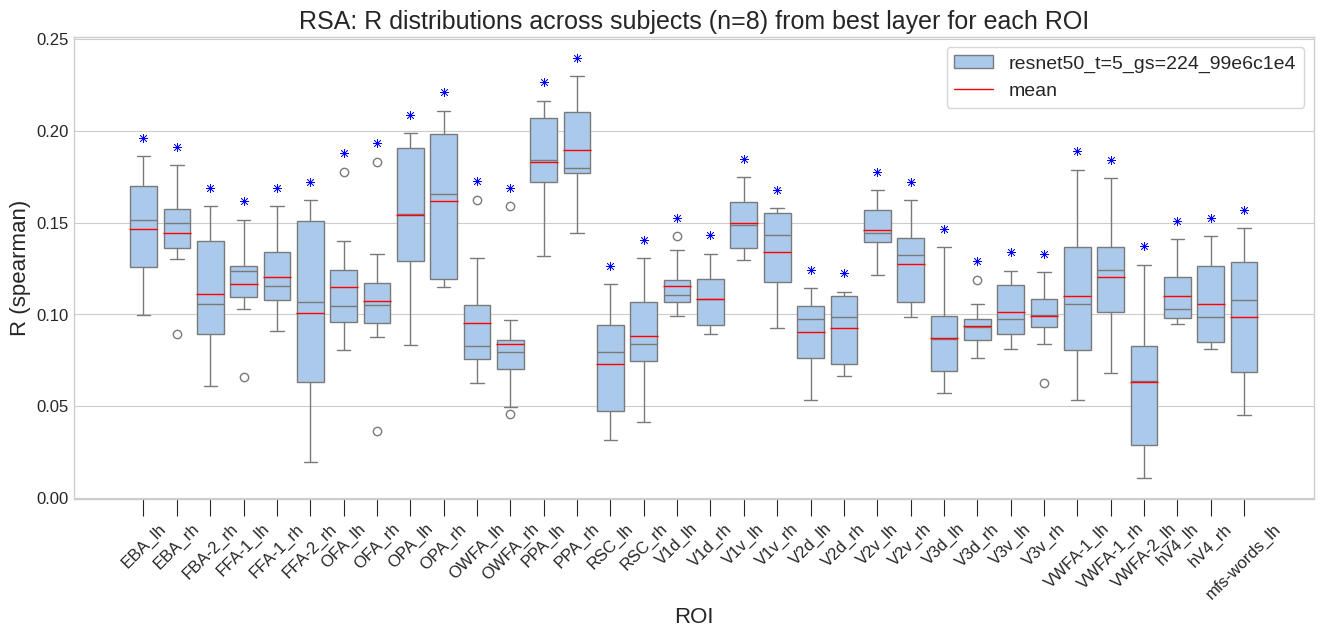

In [22]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize = (16,6))

sns.boxplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_rsa, showmeans=True, meanprops={"marker":"_", 
                       "markeredgecolor":"red",
                      "markersize":"20"}, ax=ax)

rois, idx = np.unique(plotting_df_rsa["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_df_rsa.groupby("ROI")["R"].agg("max")+0.01
y.reset_index(inplace=True, drop=True)
mask = plotting_df_rsa["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df["LNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')
#ax.hlines(plotting_df["UNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')

ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (spearman)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
current_handles_labels = ax.get_legend_handles_labels()
obj_list = [current_handles_labels[0][0], Line2D([0], [0], color="red", lw=1)]
label_list = [current_handles_labels[1][0], "mean"]
plt.legend(obj_list, label_list, fontsize=14, frameon=True)
ax.set_title("RSA: R distributions across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "RSA_R_distribution.pdf"), format='PDF', bbox_inches='tight')
#plt.show()

Text(0.5, 1.0, 'RSA: Mean R across subjects (n=8) from best layer for each ROI')

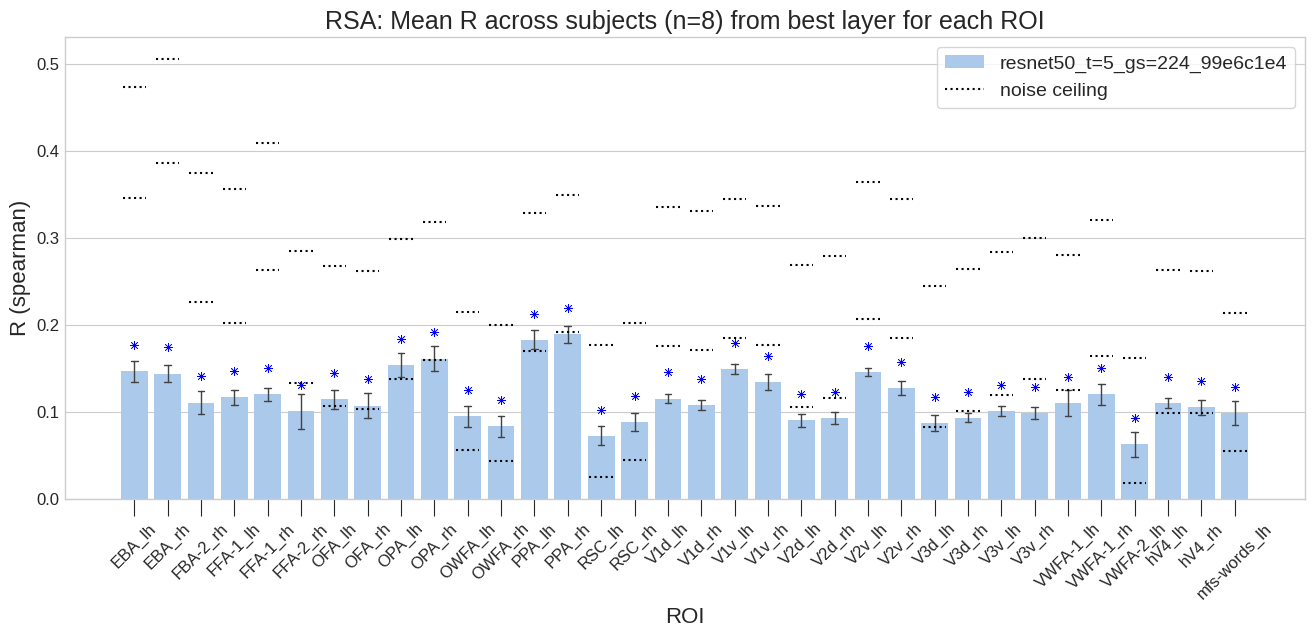

In [23]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_rsa, errorbar='se', capsize=0.2, errwidth=1)
rois, idx = np.unique(plotting_df_rsa["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_df_rsa.groupby("ROI")["R"].agg("mean")+0.03
y.reset_index(inplace=True, drop=True)
mask = plotting_df_rsa["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

ax.hlines(plotting_df_rsa["LNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
ax.hlines(plotting_df_rsa["UNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (spearman)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("RSA: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "RSA_Mean_R.pdf"), format='PDF', bbox_inches='tight')

In [24]:
plotting_pooled = rsa_pooled_fdr.copy()
plotting_pooled = plotting_pooled.loc[plotting_pooled.groupby('ROI')["R"].idxmax()]
plotting_pooled = plotting_pooled.explode("R_array")
plotting_pooled = plotting_pooled.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})
plotting_pooled.reset_index(inplace=True, drop=True)

Text(0.5, 1.0, 'RSA: R distributions across subjects (n=8) from best layer for each ROI')

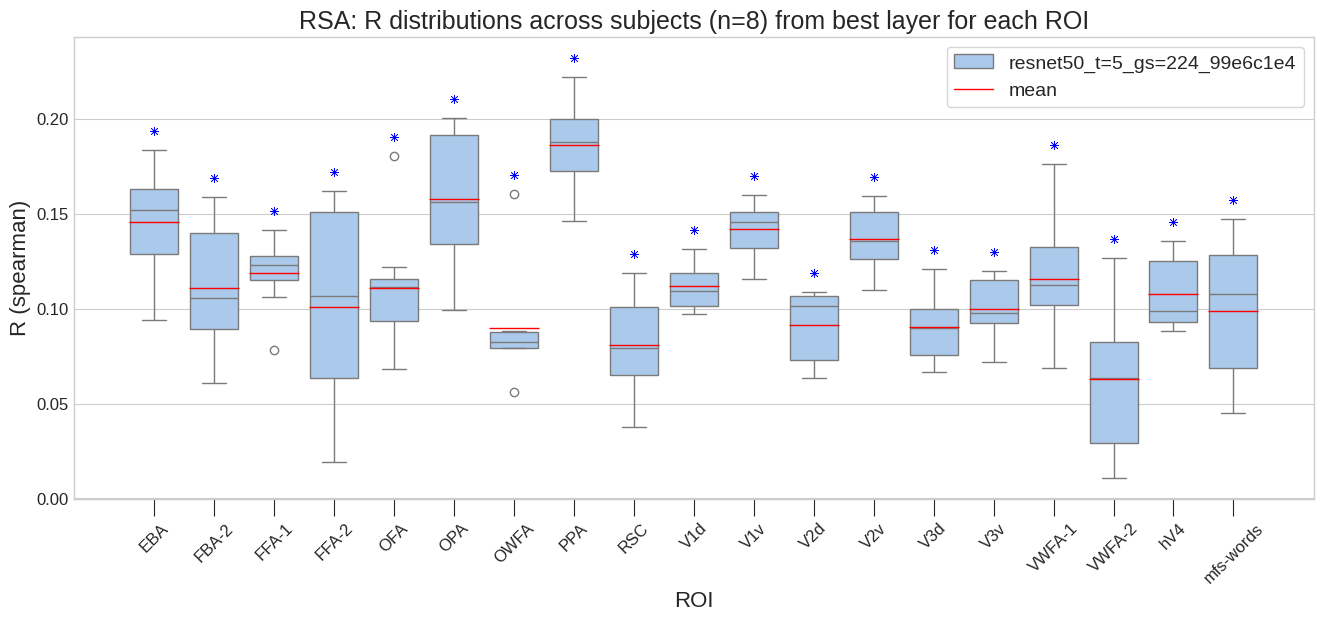

In [26]:
fig, ax = plt.subplots(figsize = (16,6))

sns.boxplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_pooled, showmeans=True, meanprops={"marker":"_", 
                       "markeredgecolor":"red",
                      "markersize":"36"}, ax=ax)

rois, idx = np.unique(plotting_pooled["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_pooled.groupby("ROI")["R"].agg("max")+0.01
y.reset_index(inplace=True, drop=True)
mask = plotting_df_rsa["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df["LNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')
#ax.hlines(plotting_df["UNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')

ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (spearman)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
current_handles_labels = ax.get_legend_handles_labels()
obj_list = [current_handles_labels[0][0], Line2D([0], [0], color="red", lw=1)]
label_list = [current_handles_labels[1][0], "mean"]
plt.legend(obj_list, label_list, fontsize=14, frameon=True)
ax.set_title("RSA: R distributions across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "RSA_R_distribution.pdf"), format='PDF', bbox_inches='tight')
#plt.show()

Text(0.5, 1.0, 'RSA: Mean R across subjects (n=8) from best layer for each ROI')

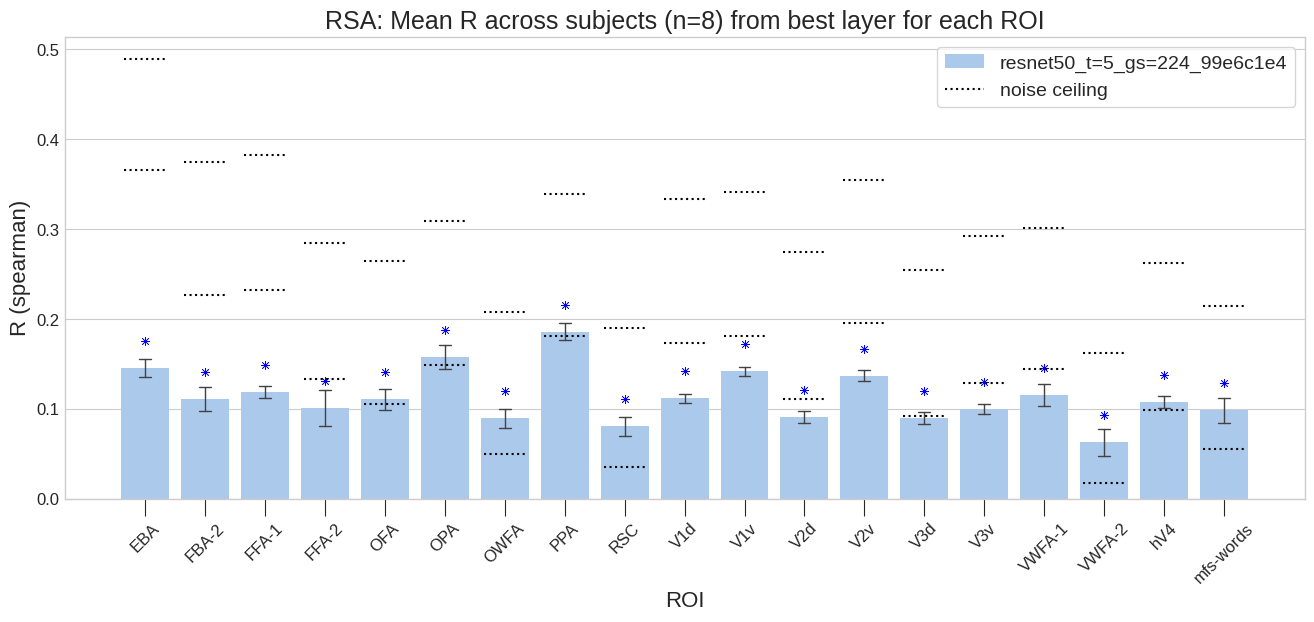

In [27]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_pooled, errorbar='se', capsize=0.2, errwidth=1)
rois, idx = np.unique(plotting_pooled["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_pooled.groupby("ROI")["R"].agg("mean")+0.03
y.reset_index(inplace=True, drop=True)
mask = plotting_pooled["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

ax.hlines(plotting_pooled["LNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
ax.hlines(plotting_pooled["UNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (spearman)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("RSA: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "RSA_Mean_R.pdf"), format='PDF', bbox_inches='tight')

Text(0.5, 1.0, 'resnet50, $\\Delta T$=5, crop=224')

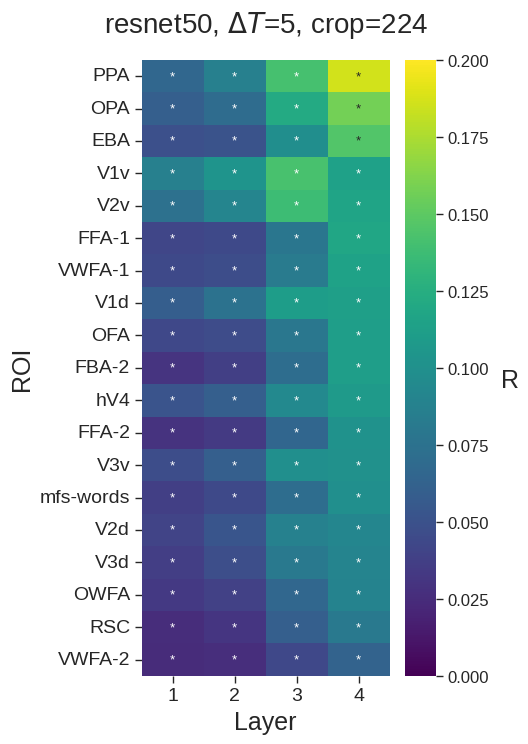

In [104]:
table = pd.pivot_table(rsa_pooled_fdr, values="R", columns="Layer", index="ROI")
sorted=table.max(axis=1).sort_values(ascending=False)
table_sorted = table.loc[sorted.index,:]

p_table = pd.pivot_table(rsa_pooled_fdr, values="Significance", columns="Layer", index="ROI") < 0.05
p_table_sorted = p_table.loc[sorted.index,:]
p_table_sorted[p_table_sorted==1]="*"

#annot = pd.pivot_table(rsa_pooled_fdr, values="SEM", columns="Layer", index="ROI")
#annot_sorted = annot.loc[sorted.index,:]

fig, ax = plt.subplots(figsize=(4,8))
sns.heatmap(table_sorted, cmap=sns.color_palette("viridis", as_cmap=True), vmin=0, vmax=0.2, annot=p_table_sorted, fmt="")
cbar = ax.collections[0].colorbar
cbar.set_label("R", rotation=0, labelpad=15)
ax.set_xticklabels([str(i) for i in range(1,5)], rotation=0)
ax.tick_params(axis='both',labelsize=14)
cax = ax.figure.axes[-1]
cax.tick_params(labelsize=12)
cax.set_label("R")
ax.set_title(f"{meta_rsa['name']}, $\Delta T$={meta_rsa['time_window']}, crop={meta_rsa['crop_size']}", pad=20)

#sns.heatmap(table_sorted, cmap=sns.cubehelix_palette(start=1.6, rot=-.9, as_cmap=True, dark=0.3), vmin=0, vmax=0.2)

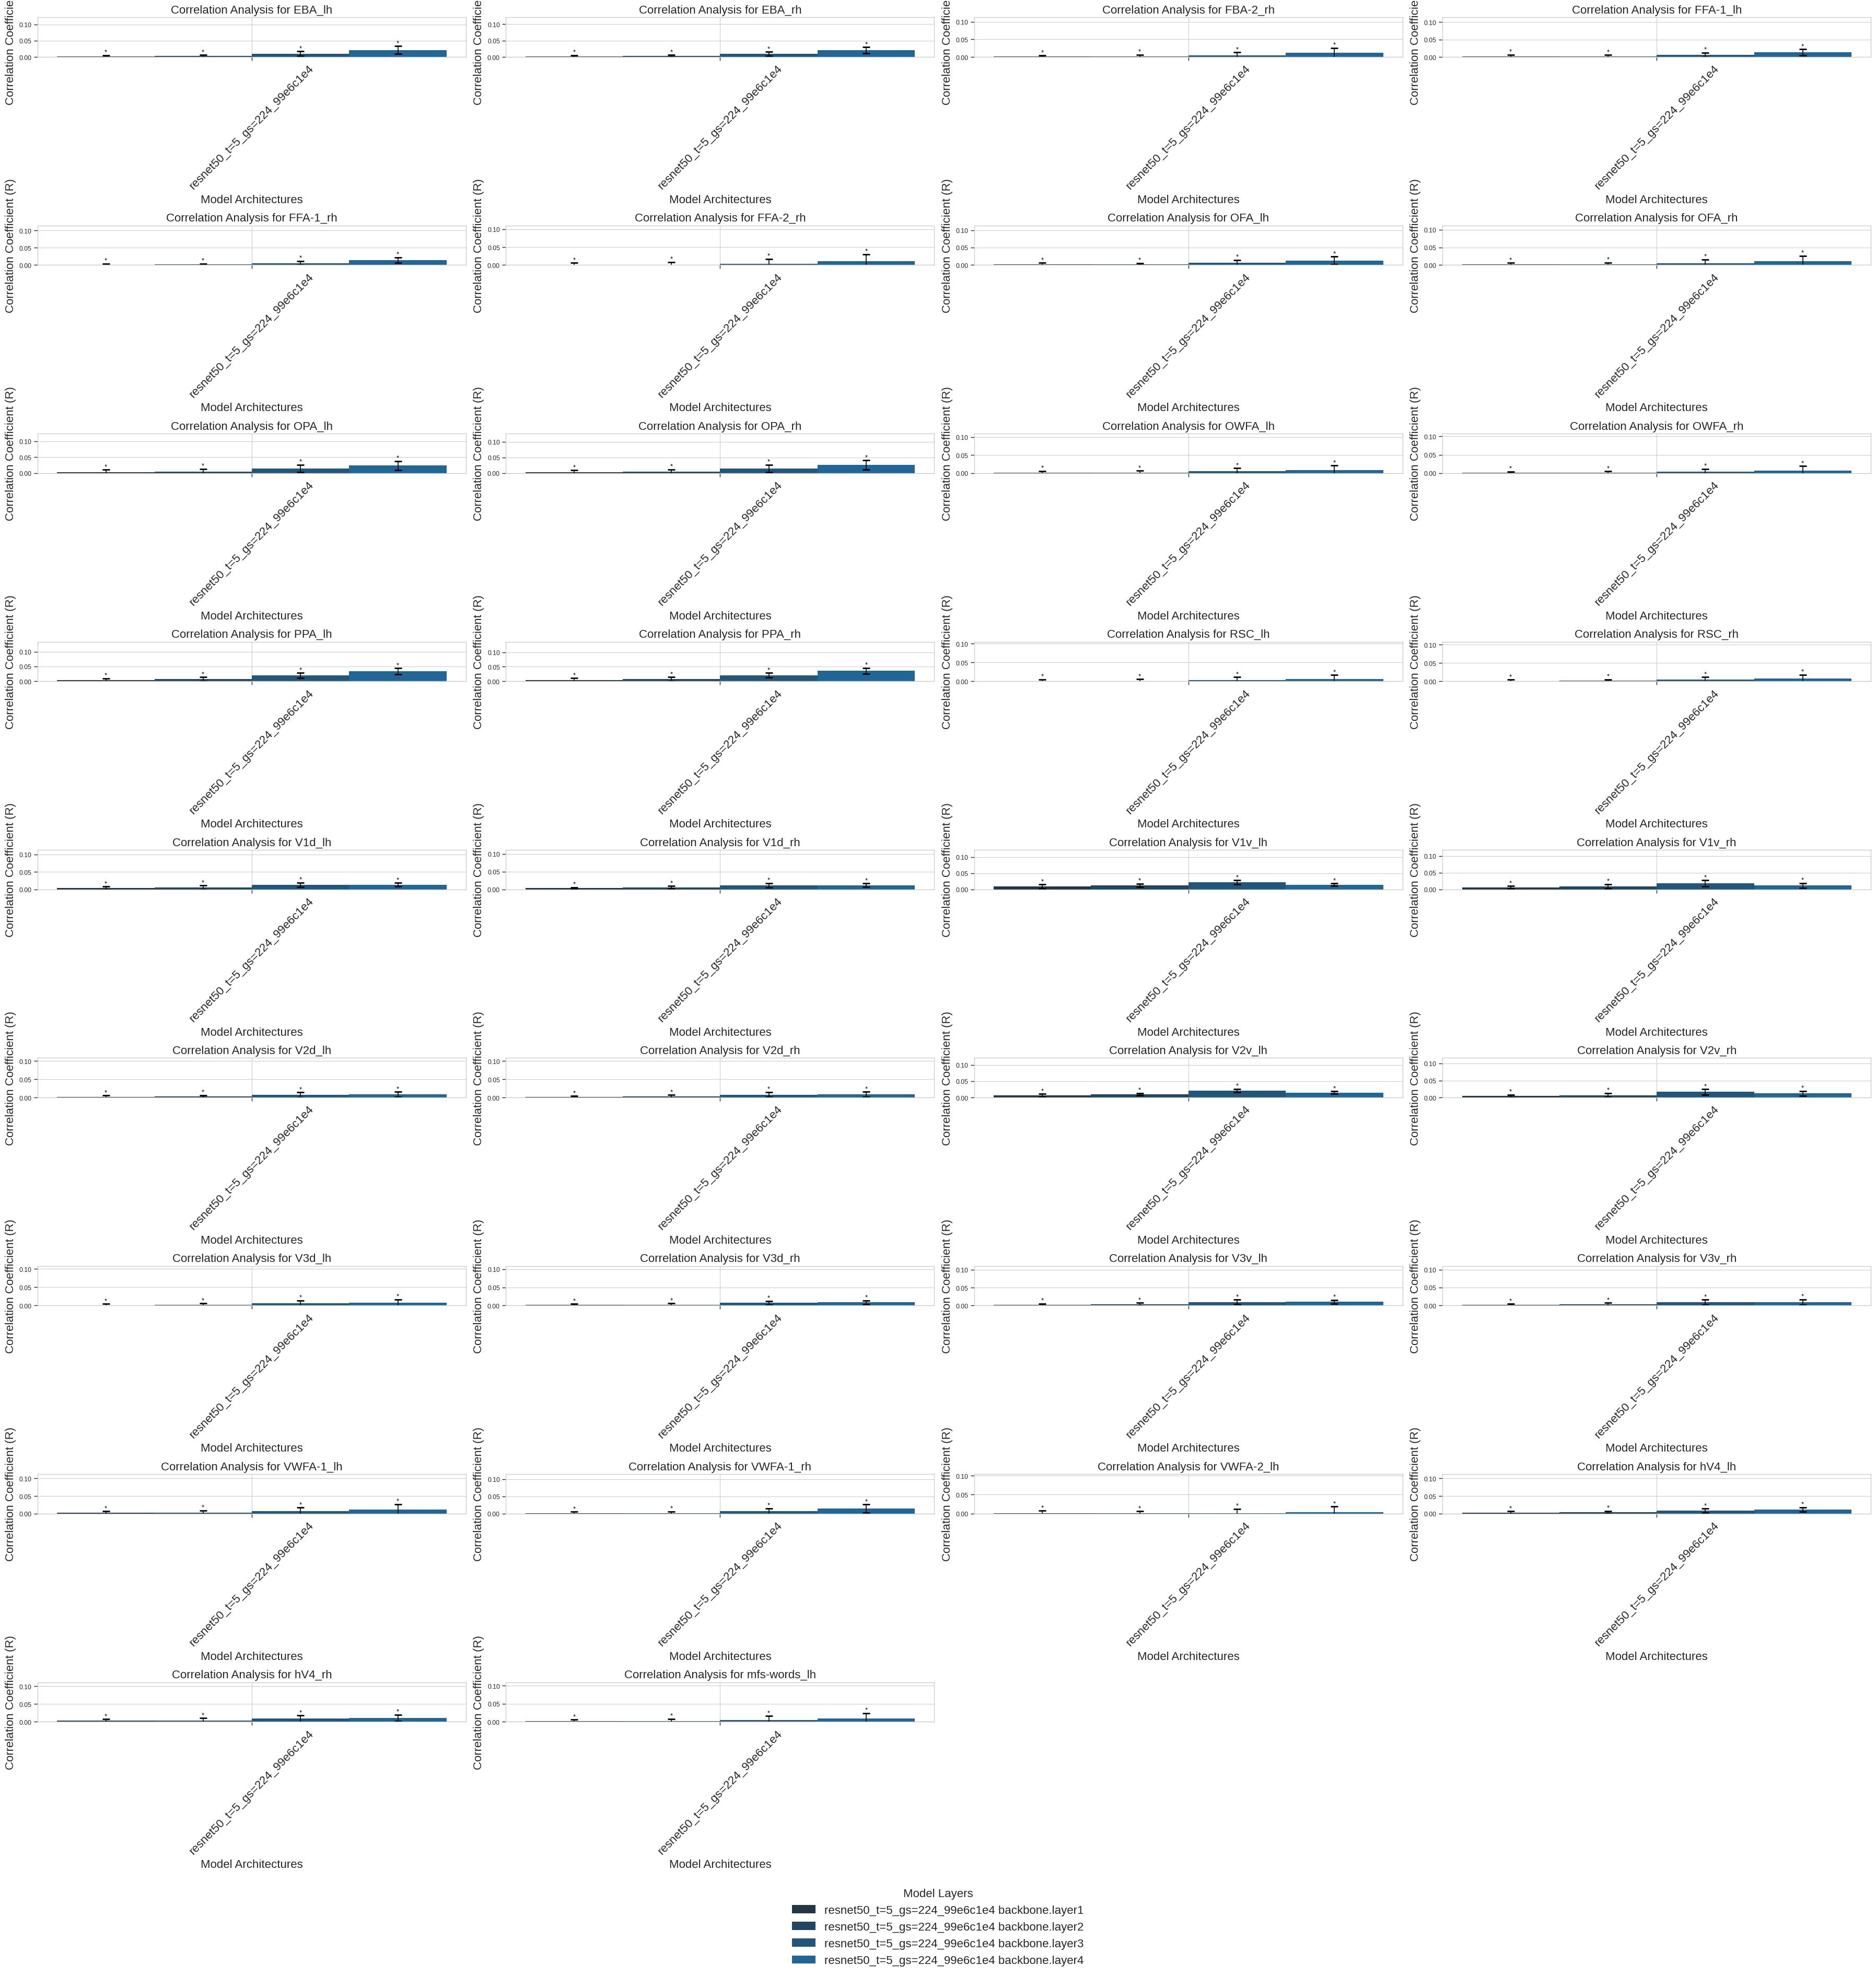

In [105]:
plotter = Plotting([rsa_df_fdr])
results_dataframe = plotter.plot_all_layers()

In [601]:
plotting_df_reg = reg_df_fdr.copy()
plotting_df_reg = plotting_df_reg.loc[plotting_df_reg.groupby('ROI')["R"].idxmax()]
plotting_df_reg = plotting_df_reg.explode("R_array")
plotting_df_reg = plotting_df_reg.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})

In [602]:
plotting_df_reg

,ROI,Layer,Model,R_mean,%R_mean,R,Significance,SEM,LNC,UNC
63,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,0.390847,0.000021,0.029466,NaN,NaN
63,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,0.374847,0.000021,0.029466,NaN,NaN
63,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,0.298079,0.000021,0.029466,NaN,NaN
63,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,0.272464,0.000021,0.029466,NaN,NaN
63,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,0.438625,0.000021,0.029466,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7,mfs-words_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.272954,NaN,0.27352,0.000149,0.036524,NaN,NaN
7,mfs-words_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.272954,NaN,0.481075,0.000149,0.036524,NaN,NaN
7,mfs-words_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.272954,NaN,0.212574,0.000149,0.036524,NaN,NaN
7,mfs-words_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.272954,NaN,0.291755,0.000149,0.036524,NaN,NaN


Text(0.5, 1.0, 'Linear Encoding: R distributions across subjects (n=8) from best layer for each ROI')

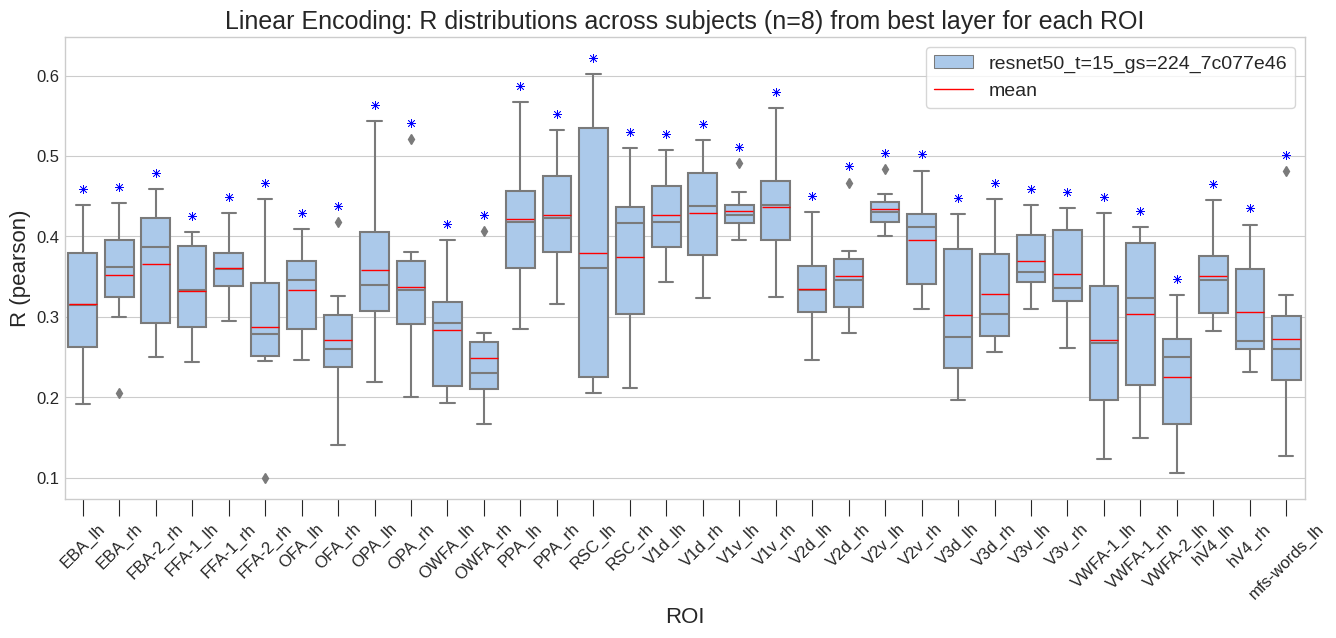

In [603]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize = (16,6))

sns.boxplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_reg, showmeans=True, meanprops={"marker":"_", 
                       "markeredgecolor":"red",
                      "markersize":"20"}, ax=ax)

rois, idx = np.unique(plotting_df_reg["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_df_reg.groupby("ROI")["R"].agg("max")+0.02
y.reset_index(inplace=True, drop=True)
mask = plotting_df_reg["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df["LNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')
#ax.hlines(plotting_df["UNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')

ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
current_handles_labels = ax.get_legend_handles_labels()
obj_list = [current_handles_labels[0][0], Line2D([0], [0], color="red", lw=1)]
label_list = [current_handles_labels[1][0], "mean"]
plt.legend(obj_list, label_list, fontsize=14, frameon=True)
ax.set_title("Linear Encoding: R distributions across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "LE_R_distribution.pdf"), format='PDF', bbox_inches='tight')
#plt.show()

Text(0.5, 1.0, 'Linear Encoding: Mean R across subjects (n=8) from best layer for each ROI')

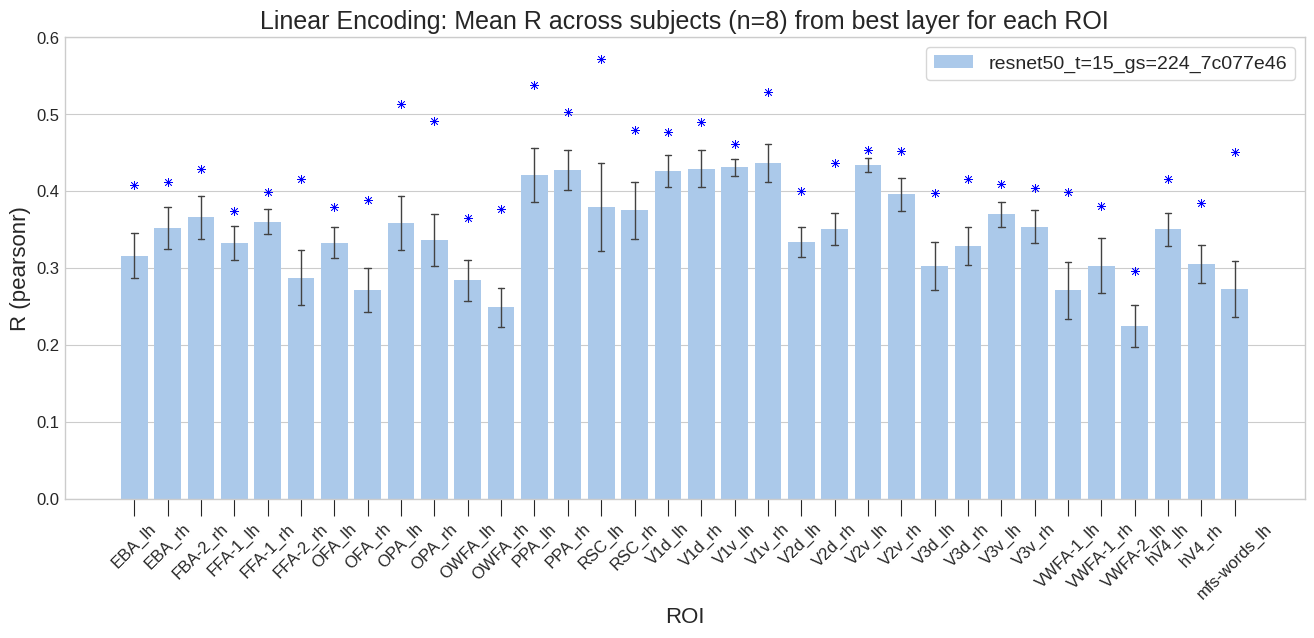

In [604]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_reg, errorbar='se', capsize=0.2, errwidth=1)
rois, idx = np.unique(plotting_df_reg["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_df_reg.groupby("ROI")["R"].agg("max")-0.03
y.reset_index(inplace=True, drop=True)
mask = plotting_df_reg["Significance"].iloc[idx] < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df_reg["LNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(plotting_df_reg["UNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearsonr)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("Linear Encoding: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
#plt.savefig(os.path.join("results",results_dir, "LE_Mean_R.pdf"), format='PDF', bbox_inches='tight')

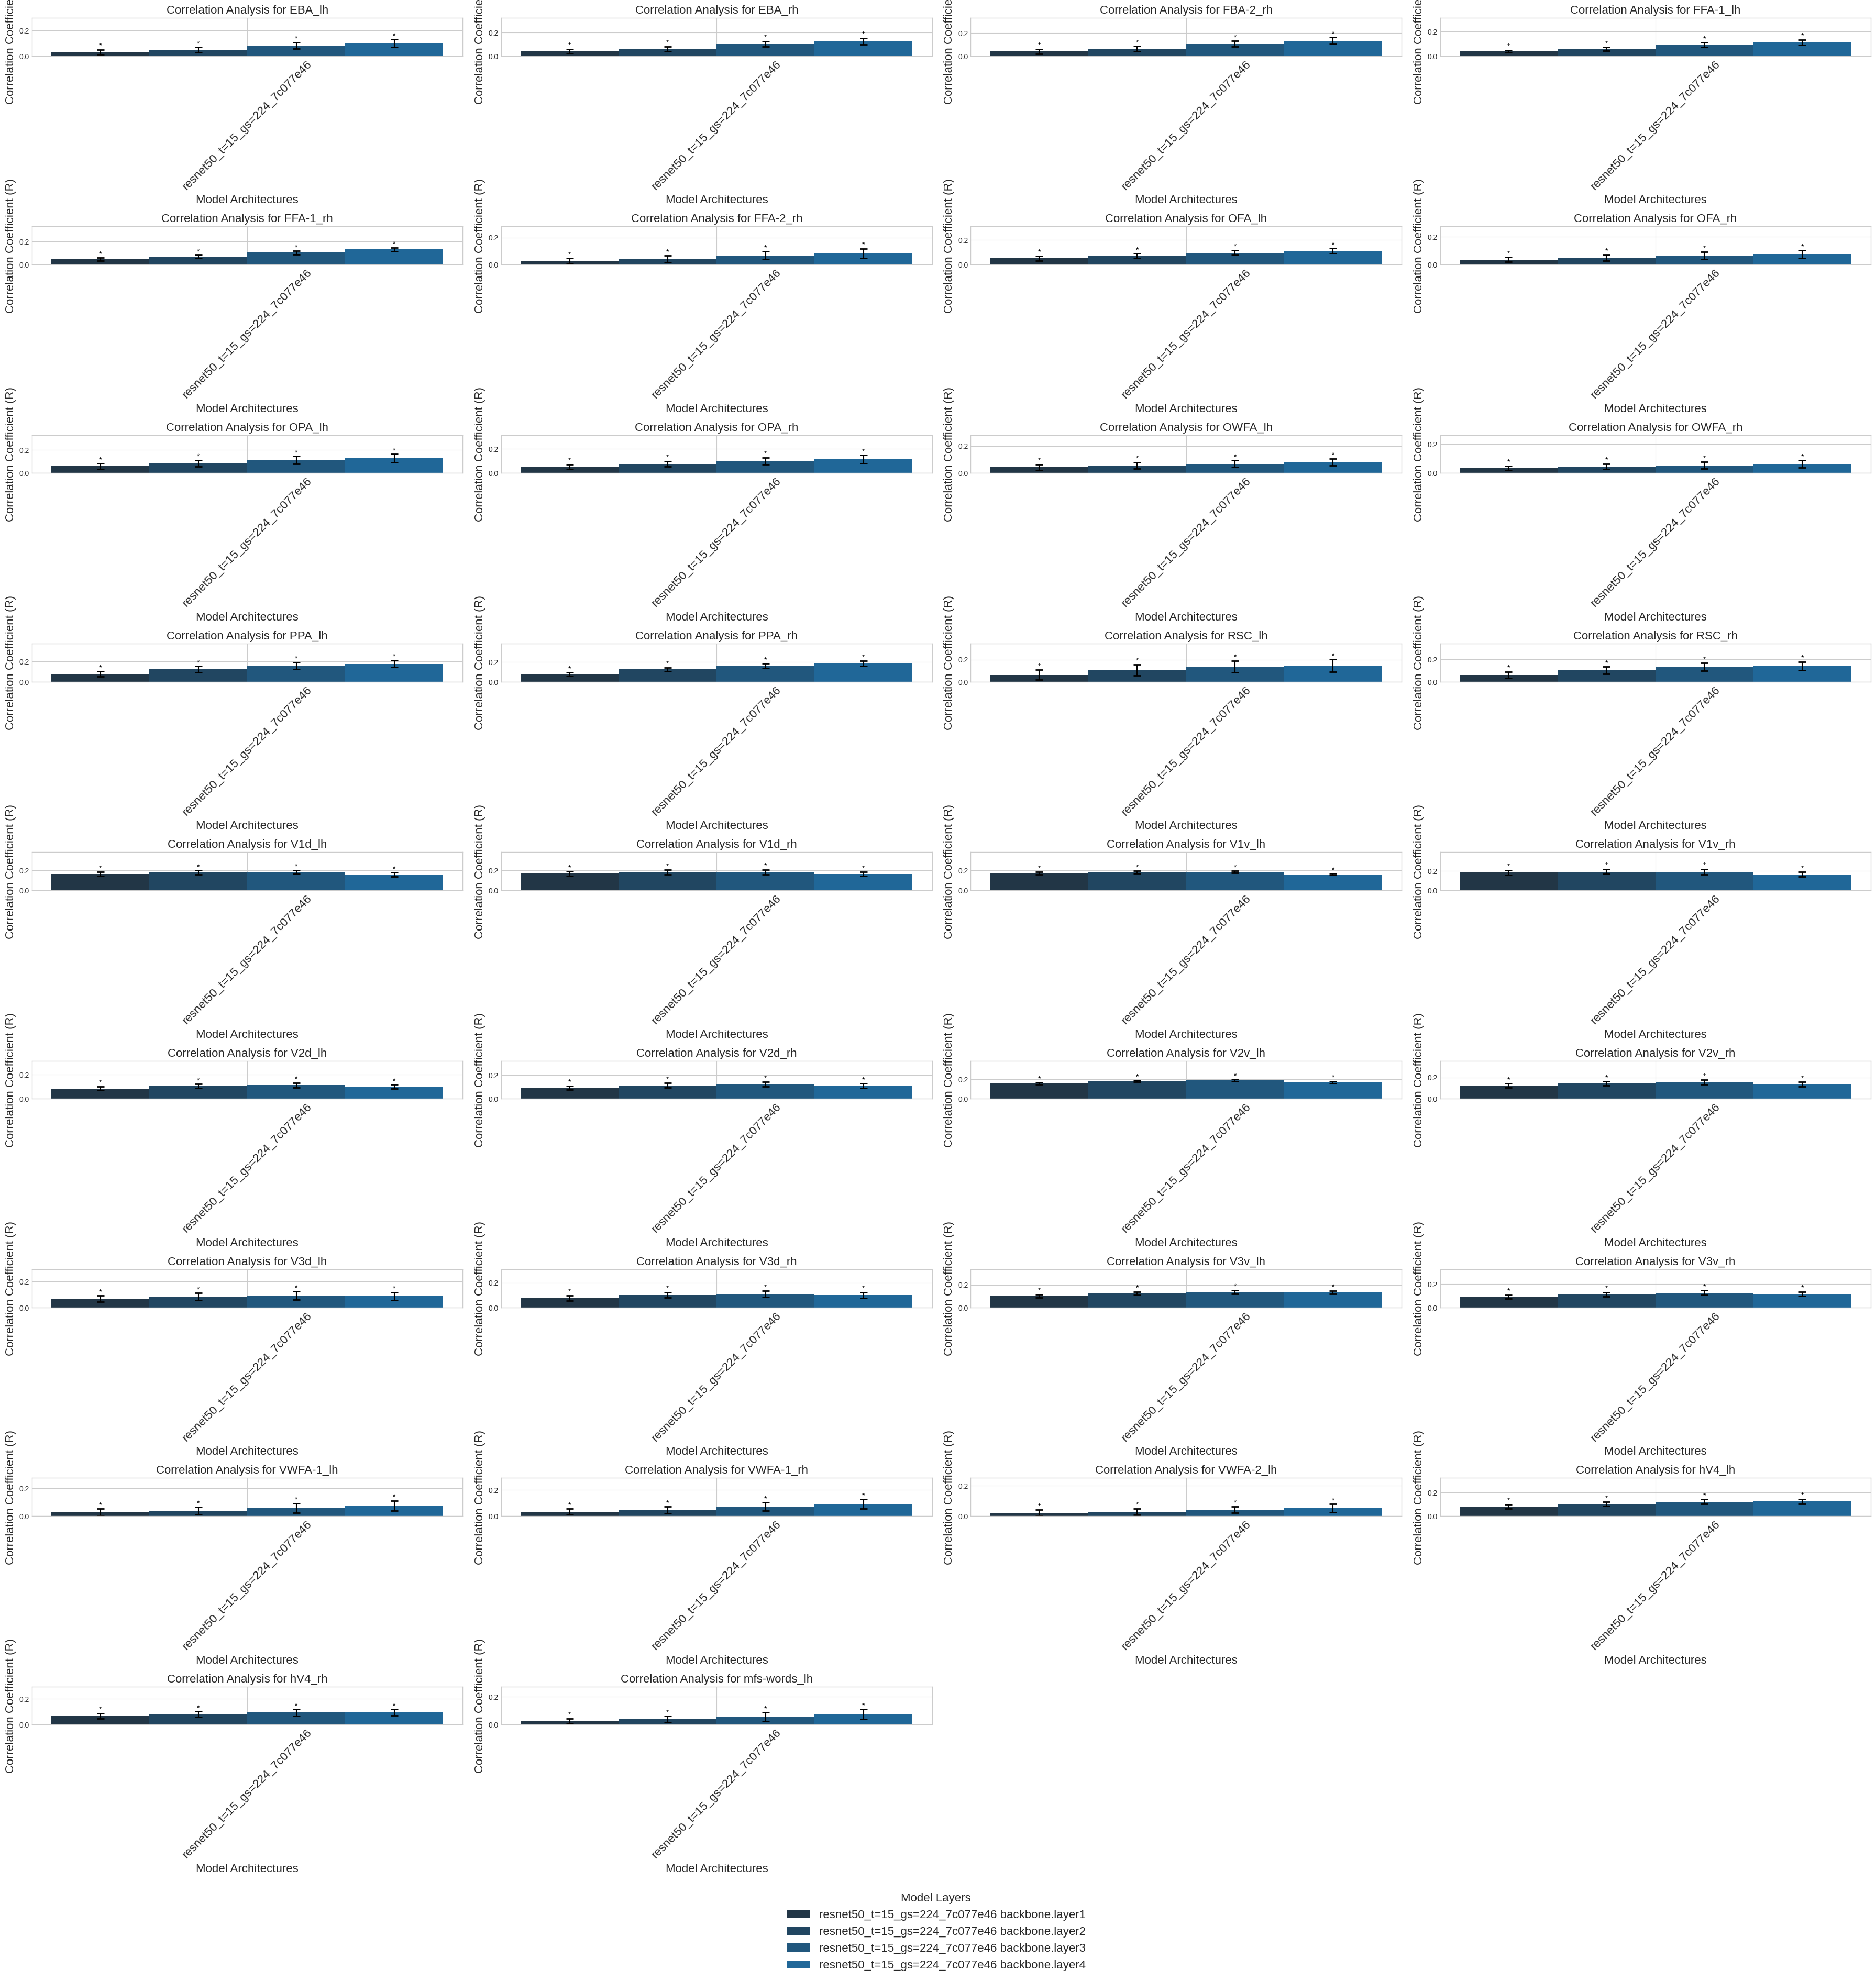

In [605]:
plotter = Plotting([reg_df_fdr])
results_dataframe = plotter.plot_all_layers()

# Model comparison RSA

In [606]:
results_dropdown_1 = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown_1)


results_dropdown_2 = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown_2)

Dropdown(options=('resnet50_t=15_gs=224_7c077e46', 'LE_side_by_side.pdf', 'resnet50_t=0_gs=224_c55ac28d', 'RSA…

Dropdown(options=('resnet50_t=15_gs=224_7c077e46', 'LE_side_by_side.pdf', 'resnet50_t=0_gs=224_c55ac28d', 'RSA…

In [658]:
results_dir_1 = results_dropdown_1.value
print(results_dir_1)
results_dir_2 = results_dropdown_2.value
print(results_dir_2)

resnet50_t=15_gs=224_7c077e46
resnet50_t=0_gs=224_c55ac28d


In [659]:
with open(os.path.join("results",results_dir_1, "config.yaml"), 'r') as f:
    config_1 = yaml.safe_load(f)
with open(os.path.join("results",results_dir_2, "config.yaml"), 'r') as f:
    config_2 = yaml.safe_load(f)

rdm_path_1 = "tmp/rdms/" + results_dir_1 + "_rdm"
rdm_path_2 = "tmp/rdms/" + results_dir_2 + "_rdm"
brain_rdms = config_1["data"]["brain_rdms"]

In [660]:
table1 = pq.read_table(os.path.join("results", results_dir_1, "eval_df_rsa.parquet"), partitioning=None)
table2 = pq.read_table(os.path.join("results", results_dir_2, "eval_df_rsa.parquet"), partitioning=None)

dataframe1 = table1.to_pandas()
dataframe2 = table2.to_pandas()

In [661]:
with open(os.path.join("results",results_dir_1, "RSA_instance.pkl"), 'rb') as f:
    evaluation_1 = pickle.load(f)

with open(os.path.join("results",results_dir_2, "RSA_instance.pkl"), 'rb') as f:
    evaluation_2 = pickle.load(f)

In [662]:
ttest, sig_pairs = evaluation_1.compare_model(evaluation_2)

In [670]:
sig_pairs_renamed = []
for pair in sig_pairs:
    new_name = pair[0][0].split(") ")[1]
    new_name = new_name.split("_RDMs")[0]
    new_pair = [(new_name,  pair[0][1]), (new_name, pair[1][1])]
    sig_pairs_renamed.append(new_pair)

In [671]:
plotting_df_1 = dataframe1.copy()
plotting_df_1 = plotting_df_1.loc[plotting_df_1.groupby('ROI')["R"].idxmax()]
plotting_df_2 = dataframe2.copy()
plotting_df_2 = plotting_df_2.loc[plotting_df_2.groupby('ROI')["R"].idxmax()]

In [672]:
plotting_compare_df = pd.concat([plotting_df_1, plotting_df_2])

In [673]:
plotting_compare_df = plotting_compare_df.explode("R_array")
plotting_compare_df = plotting_compare_df.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})

In [674]:
means_R_1 = plotting_df_1["R"]
means_R_2 = plotting_df_2["R"]

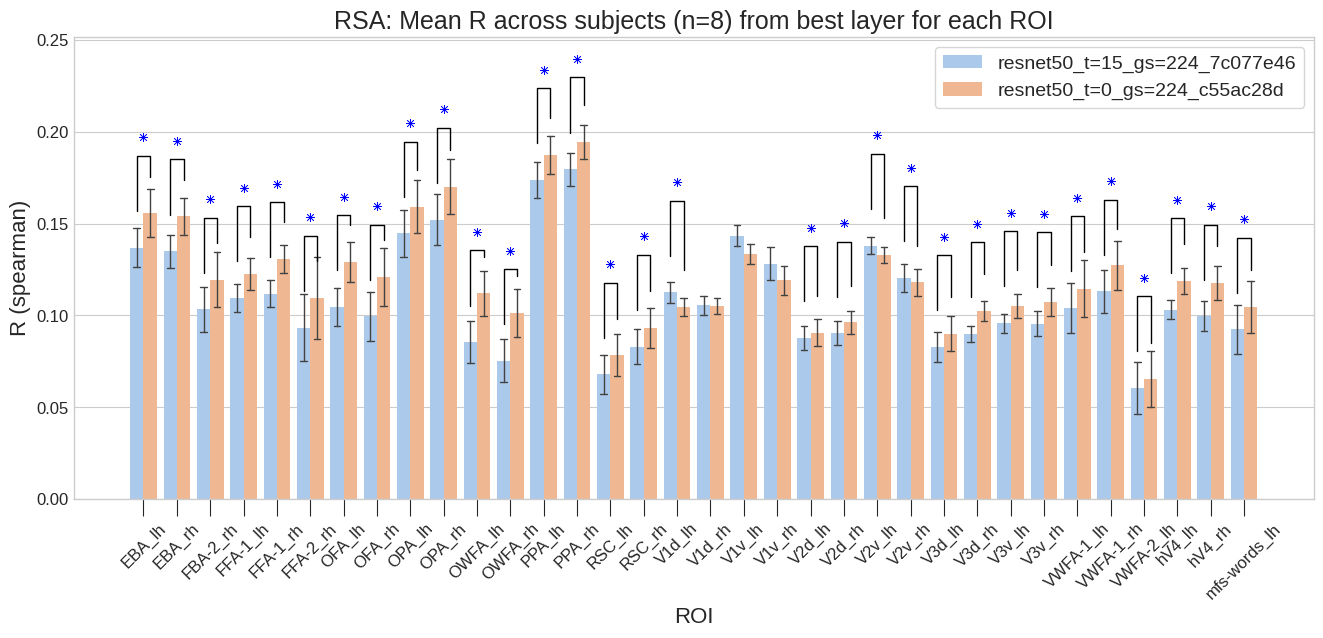

In [676]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_compare_df, errorbar='se', capsize=0.2, errwidth=1)
rois, idx = np.unique(plotting_compare_df["ROI"].to_numpy(), return_index=True)
x1 = np.arange(len(rois))+0.2
x2 = np.arange(len(rois))-0.2


y1 = means_R_1+0.02
y2 = means_R_1+0.05
y3 = means_R_2+0.02

sig_rois = [sig_pairs_renamed[i][0][0] for i in range(len(sig_pairs))]
sig_mask = [roi in sig_rois for roi in rois]
y1 = y1[sig_mask]
y2 = y2[sig_mask]
y3 = y3[sig_mask]
plt.plot([x1[sig_mask] ,x1[sig_mask], x2[sig_mask], x2[sig_mask]], [y3, y2, y2, y1], linewidth=1, color='k')

x = np.arange(len(rois))[sig_mask]
y = y2 +0.01
ax.scatter(x,y, marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_compare_df["LNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(plotting_compare_df["UNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (spearman)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("RSA: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
#fplt.savefig(os.path.join("results", "RSA_comparison.pdf"), format='PDF', bbox_inches='tight')

# Models side-by-side Regression

In [640]:
table1 = pq.read_table(os.path.join("results", results_dir_1, "eval_df_reg.parquet"), partitioning=None)
table2 = pq.read_table(os.path.join("results", results_dir_2, "eval_df_reg.parquet"), partitioning=None)

dataframe1 = table1.to_pandas()
dataframe2 = table2.to_pandas()

In [641]:
dataframe1.reset_index(inplace=True)
dataframe2.reset_index(inplace=True)

In [642]:
df1_fdr = dataframe1.copy()
df1_fdr["Significance"] = false_discovery_control(df1_fdr["Significance"].to_numpy())

df2_fdr = dataframe2.copy()
df2_fdr["Significance"] = false_discovery_control(df2_fdr["Significance"].to_numpy())

In [643]:
plotting_df_1 = df1_fdr.copy()
plotting_df_1 = plotting_df_1.loc[plotting_df_1.groupby('ROI')["R"].idxmax()]
plotting_df_2 = df2_fdr.copy()
plotting_df_2 = plotting_df_2.loc[plotting_df_2.groupby('ROI')["R"].idxmax()]

In [644]:
plotting_df_1

,index,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
63,3,EBA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.316509,NaN,"[0.39084655397353574, 0.37484732728816983, 0.2...",2.059404e-05,0.029466,NaN,NaN
123,3,EBA_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.352330,NaN,"[0.38330287468163576, 0.44163294222875454, 0.3...",7.421380e-06,0.026923,NaN,NaN
23,3,FBA-2_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.366205,NaN,"[0.41212517955881073, 0.36054684103078055, 0.4...",7.651128e-06,0.028236,NaN,NaN
15,3,FFA-1_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.332572,NaN,"[0.4016133051896507, 0.3832886419322086, 0.294...",3.236171e-06,0.022113,NaN,NaN
35,3,FFA-1_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.360682,NaN,"[0.3547696813734704, 0.41572443872300885, 0.36...",9.903794e-07,0.016236,NaN,NaN
107,3,FFA-2_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.287918,NaN,"[0.44616084777568865, 0.33319088068009567, 0.2...",9.990158e-05,0.036031,NaN,NaN
103,3,OFA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.333194,NaN,"[0.36434131749507476, 0.3552379877837417, 0.33...",2.017921e-06,0.020047,NaN,NaN
91,3,OFA_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.271312,NaN,"[0.32659108750056914, 0.2535161950729679, 0.29...",3.560444e-05,0.028386,NaN,NaN
75,3,OPA_lh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.358853,NaN,"[0.3936062933436731, 0.4420765637897286, 0.327...",2.832322e-05,0.035623,NaN,NaN
71,3,OPA_rh,backbone.layer4,resnet50_t=15_gs=224_7c077e46,0.337158,NaN,"[0.36080874171668115, 0.3805994546982929, 0.30...",2.962957e-05,0.033809,NaN,NaN


In [645]:
sig_mask_1 = plotting_df_1["Significance"] < 0.05
sig_mask_2 = plotting_df_2["Significance"] < 0.05
y1 = plotting_df_1["R"]+plotting_df_1["SEM"]
y2 = plotting_df_2["R"]+plotting_df_2["SEM"]

In [646]:
plotting_compare_df = pd.concat([plotting_df_1, plotting_df_2])

In [647]:
plotting_compare_df = plotting_compare_df.explode("R_array")
plotting_compare_df = plotting_compare_df.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})

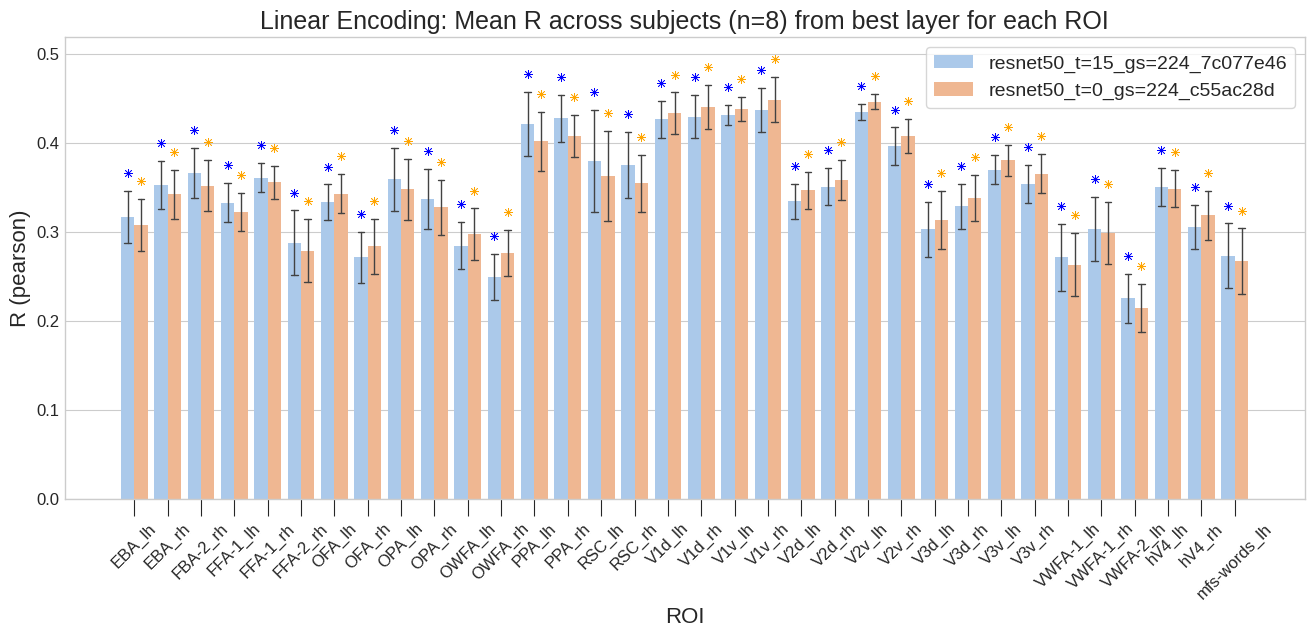

In [651]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_compare_df, errorbar='se', capsize=0.2, errwidth=1)
rois, idx = np.unique(plotting_compare_df["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))

ax.scatter(x-0.2,y1[sig_mask_1]+0.02, marker=(8,2,0), lw=0.5, color='b')
ax.scatter(x+0.2,y2[sig_mask_2]+0.02, marker=(8,2,0), lw=0.5, color='orange')


#ax.hlines(plotting_compare_df["LNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(plotting_compare_df["UNC"].iloc[idx], x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("Linear Encoding: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results", "LE_side_by_side.pdf"), format='PDF', bbox_inches='tight')

In [7]:
dir_1 = os.path.join("results","resnet50_t=0_gs=224_c55ac28d", "eval_df_rsa.parquet")
dir_2 = os.path.join("results","resnet50_t=15_gs=224_7c077e46", "eval_df_rsa.parquet")

rsa_table_1 = pq.read_table(os.path.join(dir_1), partitioning=None)
rsa_df_1 = rsa_table_1.to_pandas()
rsa_table_2 = pq.read_table(os.path.join(dir_2), partitioning=None)
rsa_df_2 = rsa_table_2.to_pandas()

In [17]:
best_layer_idx_1 = rsa_df_1.groupby("ROI")["R"].idxmax() # make sure index is actually from 1 to 136 
best_layer_idx_2 = rsa_df_2.groupby("ROI")["R"].idxmax()

best_layers_df_1 = rsa_df_1.iloc[best_layer_idx_1,:]
best_layers_df_1.reset_index(drop=True, inplace=True)
best_layers_df_2 = rsa_df_2.iloc[best_layer_idx_2,:]
best_layers_df_2.reset_index(drop=True, inplace=True)

In [38]:
df_new = pd.merge(best_layers_df_1[["ROI", "Layer", "Model", "R_array"]], best_layers_df_2[["ROI", "Layer", "Model", "R_array"]], on="ROI", how="inner", suffixes=("_1", "_2"))

In [39]:
from scipy.stats import ttest_rel

df_new["Significance"]=ttest_rel(np.asarray(df_new["R_array_1"].to_list()), np.asarray(df_new["R_array_2"].to_list()), axis=1)[1]

In [40]:
df_new

,ROI,Layer_1,Model_1,R_array_1,Layer_2,Model_2,R_array_2,Significance
0,EBA_lh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.19788267609929053, 0.18093266493465734, 0.1...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.17009059133731985, 0.15394355582336175, 0.1...",0.000202
1,EBA_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.15911506327657482, 0.17318405125769387, 0.1...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.14075942377614034, 0.1483206097810312, 0.14...",0.000020
2,FBA-2_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.17823530323189468, 0.1700844548114905, 0.10...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.1457439795826591, 0.1464967077080987, 0.087...",0.002292
3,FFA-1_lh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.15928105503050244, 0.133837014157657, 0.130...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.14045815814654924, 0.12347309222484087, 0.1...",0.000020
4,FFA-1_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.10984826087024475, 0.1499023341851965, 0.12...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.09285166292613693, 0.12110276163075247, 0.1...",0.000005
5,FFA-2_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.18310184984860933, 0.1772569240939819, 0.02...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.14925075930408238, 0.147521397822308, 0.026...",0.010346
6,OFA_lh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.1519043971965933, 0.096814134130477, 0.1121...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.10378406261179952, 0.07005512622091939, 0.0...",0.000258
7,OFA_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.1226003744868261, 0.10534046209184177, 0.15...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.09757072624797507, 0.08036561442105354, 0.1...",0.000150
8,OPA_lh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.19288457157410385, 0.20282158592692665, 0.1...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.1867246812173626, 0.1800057372189476, 0.150...",0.000799
9,OPA_rh,backbone.layer4,resnet50_t=0_gs=224_c55ac28d,"[0.2012225074923218, 0.2034592748479422, 0.124...",backbone.layer4,resnet50_t=15_gs=224_7c077e46,"[0.19203388833840862, 0.17113942783355215, 0.1...",0.000791
